# 篇末综合 部分观测下的状态恢复

## 学习目标与先修知识

建立估计问题，计算滤波与平滑，诊断近似和观测（observation）失效。

先修：本篇7.1—7.6：能观性（observability）、Bayes递推、Gaussian条件、近似滤波与平滑。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

你接到一组有缺测的二室读数。先决定哪些状态（state）有观测依据，再选择估计方法，最后说明结果用于实时判断还是离线重建。篇末八题分别检查这些能力，不依赖前一题的输出（output）。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
F=np.array([[.8,.2],[.2,.8]])
for H in [[1,0],[1,1]]:
    print('传感器',H,'两步能观矩阵秩',np.linalg.matrix_rank(np.vstack([H,np.array(H)@F])))

传感器 [1, 0] 两步能观矩阵秩 2
传感器 [1, 1] 两步能观矩阵秩 1


## 模型假设

所有案例为公开人工模型（model），参数（parameter）不是生理测量。隐藏真值与估计输入（input）隔离；确定性题给出全部输入，随机方法题给出固定对数似然（likelihood）和重采样（resampling）起点。综合题的模型、时刻约定和容差独立完整，不读取其他题答案。

## 数学解释与推导

建立完整估计链需要四类论证：

1. **信息**：用 $\mathcal O_L$ 说明观测能区分什么，区分状态与参数未知。
2. **递推**：离散状态用预测—更新，线性Gaussian用条件矩；缺测不能伪装成零值。
3. **近似**：单Gaussian可能丢失双峰；粒子权重、ESS和样本多样性分别检查。
4. **验证**：滤波只用观测前缀，平滑允许未来；分别用路径枚举与整段Gaussian独立核对。

比较估计时，同时查看均值、协方差（covariance）和实际使用的观测时段，解释新增信息改变了什么。

## 核心实现

下面按推导写出计算步骤；函数的输入只包含模型与当时可用的信息。

In [3]:
def kalman_filter(transition, sensor, process_covariance, measurement_variance,
                  initial_mean, initial_covariance, observations):
    F, H, Q = map(lambda x: np.array(x, float), (transition, sensor, process_covariance))
    mean, covariance = np.array(initial_mean, float), np.array(initial_covariance, float)
    result = dict(predicted_means=[], predicted_covariances=[], means=[], covariances=[], innovations=[], innovation_variances=[])
    for t, observed in enumerate(observations):
        if t:
            mean, covariance = F @ mean, F @ covariance @ F.T + Q
        result['predicted_means'].append(mean.tolist())
        result['predicted_covariances'].append(covariance.tolist())
        innovation_variance = float(H @ covariance @ H + measurement_variance)
        innovation = None if observed is None else float(observed - H @ mean)
        if observed is not None:
            gain = covariance @ H / innovation_variance
            mean = mean + gain * innovation
            # Joseph形式保留测量噪声项；数学上等于P-KSKᵀ。
            residual_map = np.eye(len(mean)) - np.outer(gain, H)
            covariance = residual_map @ covariance @ residual_map.T + np.outer(gain, gain) * measurement_variance
            covariance = (covariance + covariance.T) / 2
        result['means'].append(mean.tolist())
        result['covariances'].append(covariance.tolist())
        result['innovations'].append(innovation)
        result['innovation_variances'].append(innovation_variance)
    return result


def rts_smooth(transition, predicted_means, predicted_covariances, means, covariances):
    F = np.array(transition, float)
    smoothed_means = [np.array(x, float) for x in means]
    smoothed_covariances = [np.array(x, float) for x in covariances]
    for t in range(len(means)-2, -1, -1):
        covariance, predicted_covariance = np.array(covariances[t]), np.array(predicted_covariances[t+1])
        gain = np.linalg.solve(predicted_covariance, F @ covariance).T
        smoothed_means[t] = np.array(means[t]) + gain @ (smoothed_means[t+1] - predicted_means[t+1])
        smoothed_covariances[t] = covariance + gain @ (smoothed_covariances[t+1] - predicted_covariance) @ gain.T
        smoothed_covariances[t] = (smoothed_covariances[t] + smoothed_covariances[t].T) / 2
    return dict(means=[x.tolist() for x in smoothed_means], covariances=[x.tolist() for x in smoothed_covariances])

## 对照实验

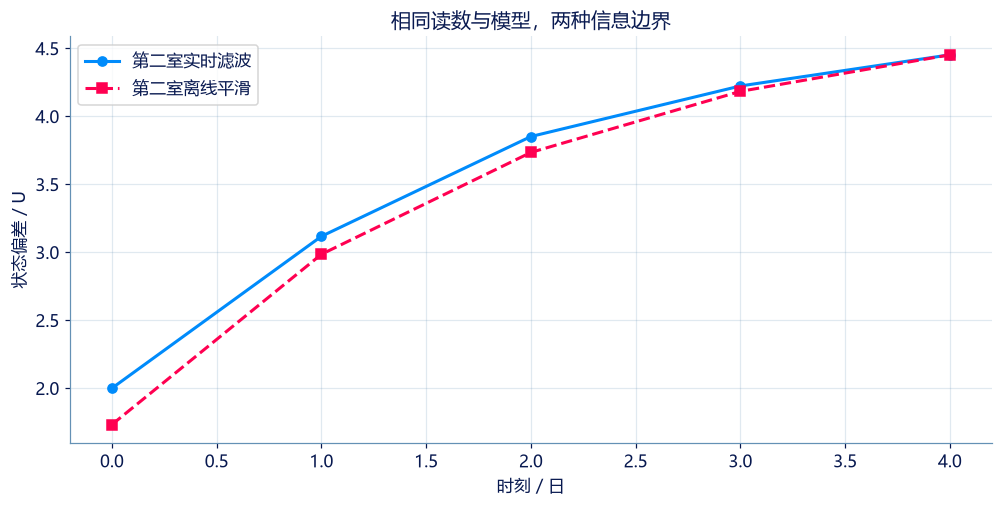

In [4]:
F=[[.8,.2],[.2,.8]];Q=[[.02,0],[0,.02]];P0=[[1,0],[0,1]];observed=[8.1,6.7,None,5.5,5.2]
run=kalman_filter(F,[1,0],Q,.16,[8,2],P0,observed);sm=rts_smooth(F,run['predicted_means'],run['predicted_covariances'],run['means'],run['covariances'])
fig,ax=plt.subplots(figsize=(9,4.5));ax.plot(np.array(run['means'])[:,1],'o-',label='第二室实时滤波');ax.plot(np.array(sm['means'])[:,1],'s--',label='第二室离线平滑');ax.set(xlabel='时刻 / 日',ylabel='状态偏差 / U',title='相同读数与模型，两种信息边界');ax.legend();plt.show()

### 独立核验与边界

In [5]:
np.testing.assert_allclose(run['means'][-1],sm['means'][-1])
assert run['innovations'][2] is None
for P in run['covariances']+sm['covariances']:assert np.linalg.eigvalsh(P).min()>-1e-12
print('综合作答前先检查：时刻、单位、矩阵方向、可用信息与独立参照。')

综合作答前先检查：时刻、单位、矩阵方向、可用信息与独立参照。


## 结果解释

滤波在每个时刻使用已经到达的读数，平滑还利用后续读数回看过去。图中的差别来自两者可用信息的不同；选择方法时，先看任务需要实时估计还是离线重建。

## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 多项选择题：辨认估计任务

二室模型（model）的F、Q、H、R已知，初始分布（distribution）已知，当前状态（state）未知。哪些判断正确？

- **A.** 当前任务是状态估计。
- **B.** 状态可观与未知参数（parameter）可辨识是同一命题。
- **C.** H=[1,1]且对称守恒交换时可能有不可观差量。
- **D.** 增加滤波器迭代可凭空补齐所有传感器信息。

[作答：辨认估计任务](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-state-task)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：保证在线信息边界

比较同一二室模型（model）的实时滤波和离线平滑。哪项设置公平且标注准确？

- **A.** 把全序列平滑估计用于时刻t的实时控制评分。
- **B.** 滤波仅用截至t的观测（observation）；平滑单独评价离线重建。
- **C.** 用核验真值选择每一步滤波增益（gain）。
- **D.** 缺測一律用后一个观测插值再称实时。

[作答：保证在线信息边界](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-information)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：隐藏状态的精确递推

一个细胞有静息、活跃、恢复三种隐藏状态（state）；给定先验（prior）、转移与实际标记的似然（likelihood），求预测与后验（posterior）。

**函数与代码模板**

```python
def solve(
    initial: list[float],
    transition: list[list[float]],
    likelihoods: list[list[float] | None],
) -> tuple[list[list[float]], list[list[float]], list[float], str]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `list[float]` | 时刻 0 的观测（observation）前概率分布（probability distribution）。 | 概率 |
| `transition` | `list[list[float]]` | 第 i 行第 j 列为从 i 转移到 j 的概率（probability）。 | 概率 |
| `likelihoods` | <code>list[list[float] &#124; None]</code> | 各时刻实际读数在各状态下的似然；None 表示缺测。 | 无量纲 |

**返回值**

按以下顺序返回元组：(predictions, posteriors, evidence, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `predictions` | `list[list[float]]` | 每一步观测前分布（distribution）。 | 概率 |
| `posteriors` | `list[list[float]]` | 成功归一化各步的滤波后验。 | 概率 |
| `evidence` | `list[float]` | 各步似然加权和。 | 无量纲 |
| `status` | `str` | 成功为 ok；首个零证据为 impossible。 | 无量纲 |

**计算规则**

时刻0直接更新initial；之后先按行随机矩阵（matrix）转移。缺测用全1似然；零证据停止，保留该步预测与证据，不生成该步后验。

**约束与边界**

- 状态数2—3，0—20时刻；初始及转移行归一化，似然在[0,1]或None。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 时刻 0 的观测（observation）前概率分布（probability distribution）。 | [0.6, 0.3, 0.1] | 概率 |
| transition | 第 i 行第 j 列为从 i 转移到 j 的概率（probability）。 | [[0.8, 0.15, 0.05], [0.1, 0.8, 0.1], [0.05, 0.2, 0.75]] | 概率 |
| likelihoods | 各时刻实际读数在各状态下的似然；None 表示缺测。 | [[0.8, 0.4, 0.1], None, [0.2, 0.6, 0.9]] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = [0.6, 0.3, 0.1]
transition = [[0.8, 0.15, 0.05],
              [0.1, 0.8, 0.1],
              [0.05, 0.2, 0.75]]
likelihoods = [[0.8, 0.4, 0.1], None, [0.2, 0.6, 0.9]]

result = solve(initial, transition, likelihoods)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| predictions | 每一步观测前分布（distribution）。 | [[0.6, 0.3, 0.1], [0.65, 0.2786885245901639, 0.07131147540983607], [0.5514344262295082, 0.3347131147540984, 0.11385245901639345]] | 概率 |
| posteriors | 成功归一化各步的滤波后验。 | [[0.7868852459016393, 0.19672131147540983, 0.016393442622950824], [0.65, 0.2786885245901639, 0.07131147540983607], [0.26666270289553484, 0.485581782507878, 0.2477555145965872]] | 概率 |
| evidence | 各步似然加权和。 | [0.61, 1.0, 0.41358196721311474] | 无量纲 |
| status | 成功为 ok；首个零证据为 impossible。 | ok | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[0.6, 0.3, 0.1],
                    [0.65,
                     0.2786885245901639,
                     0.07131147540983607],
                    [0.5514344262295082,
                     0.3347131147540984,
                     0.11385245901639345]],
                   [[0.7868852459016393,
                     0.19672131147540983,
                     0.016393442622950824],
                    [0.65,
                     0.2786885245901639,
                     0.07131147540983607],
                    [0.26666270289553484,
                     0.485581782507878,
                     0.2477555145965872]],
                   [0.61, 1.0, 0.41358196721311474],
                   'ok')
```

**样例解释**

第一步三种状态的质量为[0.48,0.12,0.01]，总和0.61；后验由这三项归一化。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：隐藏状态的精确递推](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-hidden-update)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：部分观测二室恢复

已知二室动态，给定观测（observation）而不提供真实状态（state），计算线性高斯滤波。该题可退化为一维用于边界核验。 初态为给定均值和协方差（covariance）的高斯分布（Gaussian distribution）；过程噪声（process noise）w~N(0,Q)、测量噪声（measurement noise）v~N(0,R)，初态及各时刻两种噪声相互独立。

**函数与代码模板**

```python
def solve(
    transition: list[list[float]],
    sensor: list[float],
    process_covariance: list[list[float]],
    measurement_variance: float,
    initial_mean: list[float],
    initial_covariance: list[list[float]],
    observations: list[float | None],
) -> tuple[list[list[float]], list[list[list[float]]]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | 已知状态转移矩阵（transition matrix） F。 | 无量纲 |
| `sensor` | `list[float]` | 标量读数的观测行 H。 | 无量纲 |
| `process_covariance` | `list[list[float]]` | 一步过程噪声协方差 Q。 | U² |
| `measurement_variance` | `float` | 测量噪声方差（variance） R。 | U² |
| `initial_mean` | `list[float]` | 时刻 0 观测前均值。 | U |
| `initial_covariance` | `list[list[float]]` | 时刻 0 观测前协方差。 | U² |
| `observations` | <code>list[float &#124; None]</code> | 从时刻 0 开始的读数；None 为缺测。 | U |

**返回值**

按以下顺序返回元组：(means, covariances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[list[float]]` | 各时刻使用当时可用观测后的均值。 | U |
| `covariances` | `list[list[list[float]]]` | 与 means 对应的协方差矩阵（covariance matrix）。 | U² |

**计算规则**

初始矩为t=0观测前；之后先F预测并加Q。每个非None读数按标量创新进行更新；None只预测。返回每个请求时刻的滤波矩。

**约束与边界**

- 维数1或2，0—20时刻；R>0，Q半正定（positive semidefinite），P0正定（positive definite）；输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transition | 已知状态转移矩阵（transition matrix） F。 | [[0.85, 0.1], [0.1, 0.8]] | 无量纲 |
| sensor | 标量读数的观测行 H。 | [1.0, 0.0] | 无量纲 |
| process_covariance | 一步过程噪声协方差 Q。 | [[0.02, 0.0], [0.0, 0.02]] | U² |
| measurement_variance | 测量噪声方差（variance） R。 | 0.16 | U² |
| initial_mean | 时刻 0 观测前均值。 | [2.0, 0.0] | U |
| initial_covariance | 时刻 0 观测前协方差。 | [[1.0, 0.2], [0.2, 1.0]] | U² |
| observations | 从时刻 0 开始的读数；None 为缺测。 | [1.8, None, 1.4, 0.8] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transition = [[0.85, 0.1], [0.1, 0.8]]
sensor = [1.0, 0.0]
process_covariance = [[0.02, 0.0], [0.0, 0.02]]
measurement_variance = 0.16
initial_mean = [2.0, 0.0]
initial_covariance = [[1.0, 0.2], [0.2, 1.0]]
observations = [1.8, None, 1.4, 0.8]

result = solve(transition, sensor, process_covariance, measurement_variance, initial_mean, initial_covariance, observations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 各时刻使用当时可用观测后的均值。 | [[1.8275862068965518, -0.03448275862068965], [1.55, 0.15517241379310348], [1.3644668222672294, 0.30965380875536136], [1.049540814225377, 0.24735658690180073]] | U |
| covariances | 与 means 对应的协方差矩阵（covariance matrix）。 | [[[0.13793103448275856, 0.027586206896551724], [0.027586206896551724, 0.9655172413793104]], [[0.13399999999999995, 0.10800000000000001], [0.10800000000000001, 0.6437241379310347]], [[0.07512280840151575, 0.07289249555978192], [0.07289249555978192, 0.3880034045083007]], [[0.057823964703489, 0.056018990332502044], [0.05601899033250203, 0.25002325807328124]]] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.8275862068965518,
                     -0.03448275862068965],
                    [1.55, 0.15517241379310348],
                    [1.3644668222672294,
                     0.30965380875536136],
                    [1.049540814225377,
                     0.24735658690180073]],
                   [[[0.13793103448275856,
                      0.027586206896551724],
                     [0.027586206896551724,
                      0.9655172413793104]],
                    [[0.13399999999999995,
                      0.10800000000000001],
                     [0.10800000000000001,
                      0.6437241379310347]],
                    [[0.07512280840151575,
                      0.07289249555978192],
                     [0.07289249555978192,
                      0.3880034045083007]],
                    [[0.057823964703489,
                      0.056018990332502044],
                     [0.05601899033250203,
                      0.25002325807328124]]])
```

**样例解释**

首个读数1.8小于预测2，第一室均值向下调整；初始交叉协方差使第二室也获得信息。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：部分观测二室恢复](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-gaussian-filter)

### 第 5 题 · 综合验证 · 15 分 · 多项选择题：比较近似与真实后验

相同平方观测（observation）模型（model）中，m=0，先验（prior）对称，读数提示|x|≈2。网格得到双峰，EKF和UKF都只保存一个高斯。哪些结论合理？

- **A.** 均值都接近0足以说明两种高斯表示完整正确。
- **B.** 应比较密度形状和方差（variance），不能只看均值。
- **C.** UKF的观测前矩准确就保证后验（posterior）高斯准确。
- **D.** 粒子法可表示多峰，但须检查支持和退化。

[作答：比较近似与真实后验](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-approximation)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：固定随机输入的粒子更新

相同非线性观测（observation）下，给定已经传播的粒子及其观测对数似然（likelihood），执行确定的权重更新和系统性重采样（systematic resampling）。

**函数与代码模板**

```python
def solve(
    particles: list[float],
    weights: list[float],
    log_likelihoods: list[float | None],
    offset: float,
) -> tuple[list[float], float, list[int], list[float], str]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `particles` | `list[float]` | 已传播到当前时刻的状态（state）样本。 | U |
| `weights` | `list[float]` | 上一步归一化权重。 | 概率 |
| `log_likelihoods` | <code>list[float &#124; None]</code> | 当前观测的对数似然；None 表示零似然。 | 无量纲 |
| `offset` | `float` | 系统性重采样的单位起点 u，0≤u<1。 | 无量纲 |

**返回值**

按以下顺序返回元组：(normalized, ess, indices, resampled, status)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `normalized` | `list[float]` | 观测加权后的权重，重采样（resampling）前。 | 概率 |
| `ess` | `float` | 1/sum(w²)。 | 个 |
| `indices` | `list[int]` | 系统性重采样选中的祖先下标，从 0 开始。 | 无量纲 |
| `resampled` | `list[float]` | 按祖先下标取得的粒子。 | U |
| `status` | `str` | ok 或 impossible。 | 无量纲 |

**计算规则**

位置为(offset+i)/N，选择累积质量严格大于位置的最小下标；稳定归一化已有权重乘似然。全部无质量返回([],0,[],[],"impossible")。返回重采样前权重。

**约束与边界**

- 1—100粒子；权重非负且和为1；对数似然有限或None；0≤offset<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| particles | 已传播到当前时刻的状态（state）样本。 | [-2.0, -1.0, 1.0, 2.0] | U |
| weights | 上一步归一化权重。 | [0.1, 0.2, 0.3, 0.4] | 概率 |
| log_likelihoods | 当前观测的对数似然；None 表示零似然。 | [-1000.0, -1001.0, -1002.0, -1003.0] | 无量纲 |
| offset | 系统性重采样的单位起点 u，0≤u<1。 | 0 | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
particles = [-2.0, -1.0, 1.0, 2.0]
weights = [0.1, 0.2, 0.3, 0.4]
log_likelihoods = [-1000.0, -1001.0, -1002.0, -1003.0]
offset = 0.0

result = solve(particles, weights, log_likelihoods, offset)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| normalized | 观测加权后的权重，重采样（resampling）前。 | [0.42718375165595135, 0.31430423967340587, 0.17343910207330068, 0.08507290659734217] | 概率 |
| ess | 1/sum(w²)。 | ≈ 3.138814 | 个 |
| indices | 系统性重采样选中的祖先下标，从 0 开始。 | [0, 0, 1, 2] | 无量纲 |
| resampled | 按祖先下标取得的粒子。 | [-2.0, -2.0, -1.0, 1.0] | U |
| status | ok 或 impossible。 | ok | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.42718375165595135,
                    0.31430423967340587,
                    0.17343910207330068,
                    0.08507290659734217],
                   3.1388143701042233,
                   [0, 0, 1, 2],
                   [-2.0, -2.0, -1.0, 1.0],
                   'ok')
```

**样例解释**

减去最大对数权重避免-1000附近指数下溢；所得概率（probability）不受共同平移影响。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：固定随机输入的粒子更新](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-particle)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：缺测记录的后向重建

给定同一次部分观测（observation）滤波保存的矩，计算RTS平滑，核对未来信息如何修正历史。

**函数与代码模板**

```python
def solve(
    transition: list[list[float]],
    predicted_means: list[list[float]],
    predicted_covariances: list[list[list[float]]],
    means: list[list[float]],
    covariances: list[list[list[float]]],
) -> tuple[list[list[float]], list[list[list[float]]]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | 已知状态（state）转移矩阵（transition matrix） F。 | 无量纲 |
| `predicted_means` | `list[list[float]]` | 每时刻观测前的均值，长度 T。 | U |
| `predicted_covariances` | `list[list[list[float]]]` | 每时刻观测前协方差（covariance）。 | U² |
| `means` | `list[list[float]]` | 每时刻滤波后的均值。 | U |
| `covariances` | `list[list[list[float]]]` | 每时刻滤波后的协方差。 | U² |

**返回值**

按以下顺序返回元组：(means, covariances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[list[float]]` | 各时刻使用当时可用观测后的均值。 | U |
| `covariances` | `list[list[list[float]]]` | 与 means 对应的协方差矩阵（covariance matrix）。 | U² |

**计算规则**

末端等于滤波；后向增益（gain）用P_f[t] Fᵀ inv(P_pred[t+1])。更新均值与协方差均使用下一时刻的平滑量减预测量。空输入（input）返回两个空列表。

**约束与边界**

- 维数1或2、0—20时刻；各数组（array）等长、来自同一合法滤波，预测协方差正定（positive definite）。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transition | 已知状态（state）转移矩阵（transition matrix） F。 | [[0.85, 0.1], [0.1, 0.8]] | 无量纲 |
| predicted_means | 每时刻观测前的均值，长度 T。 | [[2.0, 0.0], [1.55, 0.15517241379310348], [1.3330172413793104, 0.2791379310344828], [1.190762179802681, 0.38416972923101195]] | U |
| predicted_covariances | 每时刻观测前协方差（covariance）。 | [[[1.0, 0.2], [0.2, 1.0]], [[0.13399999999999998, 0.10800000000000001], [0.10800000000000001, 0.6437241379310346]], [[0.14161224137931033, 0.13740793103448276], [0.1374079310344828, 0.45060344827586224]], [[0.09054798736034109, 0.0877215330110424], [0.0877215330110424, 0.28073620625889273]]] | U² |
| means | 每时刻滤波后的均值。 | [[1.8275862068965518, -0.03448275862068965], [1.55, 0.15517241379310348], [1.3644668222672294, 0.30965380875536125], [1.049540814225377, 0.2473565869018007]] | U |
| covariances | 每时刻滤波后的协方差。 | [[[0.13793103448275862, 0.027586206896551727], [0.027586206896551727, 0.9655172413793104]], [[0.13399999999999998, 0.10800000000000001], [0.10800000000000001, 0.6437241379310346]], [[0.07512280840151578, 0.07289249555978189], [0.07289249555978189, 0.3880034045083006]], [[0.05782396470348902, 0.05601899033250202], [0.05601899033250202, 0.25002325807328124]]] | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transition = [[0.85, 0.1], [0.1, 0.8]]
predicted_means = [[2.0, 0.0],
                   [1.55, 0.15517241379310348],
                   [1.3330172413793104, 0.2791379310344828],
                   [1.190762179802681, 0.38416972923101195]]
predicted_covariances = [[[1.0, 0.2], [0.2, 1.0]],
                         [[0.13399999999999998,
                           0.10800000000000001],
                          [0.10800000000000001,
                           0.6437241379310346]],
                         [[0.14161224137931033,
                           0.13740793103448276],
                          [0.1374079310344828,
                           0.45060344827586224]],
                         [[0.09054798736034109,
                           0.0877215330110424],
                          [0.0877215330110424,
                           0.28073620625889273]]]
means = [[1.8275862068965518, -0.03448275862068965],
         [1.55, 0.15517241379310348],
         [1.3644668222672294, 0.30965380875536125],
         [1.049540814225377, 0.2473565869018007]]
covariances = [[[0.13793103448275862, 0.027586206896551727],
                [0.027586206896551727, 0.9655172413793104]],
               [[0.13399999999999998, 0.10800000000000001],
                [0.10800000000000001, 0.6437241379310346]],
               [[0.07512280840151578, 0.07289249555978189],
                [0.07289249555978189, 0.3880034045083006]],
               [[0.05782396470348902, 0.05601899033250202],
                [0.05601899033250202, 0.25002325807328124]]]

result = solve(transition, predicted_means, predicted_covariances, means, covariances)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 各时刻使用当时可用观测后的均值。 | [[1.7779374023999095, -0.2066960074199618], [1.4832932722499381, 0.009121291687625738], [1.25350906583979, 0.15250710039727716], [1.049540814225377, 0.2473565869018007]] | U |
| covariances | 与 means 对应的协方差矩阵（covariance matrix）。 | [[[0.0922007524035971, -0.06069515722851421], [-0.060695157228514277, 0.7848678681076177]], [[0.06782121168719134, 0.015436352827362013], [0.015436352827361957, 0.5092615220392628]], [[0.054921420652057365, 0.04428177296312662], [0.04428177296312661, 0.3474827503010318]], [[0.05782396470348902, 0.05601899033250202], [0.05601899033250202, 0.25002325807328124]]] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.7779374023999095,
                     -0.2066960074199618],
                    [1.4832932722499381,
                     0.009121291687625738],
                    [1.25350906583979, 0.15250710039727716],
                    [1.049540814225377,
                     0.2473565869018007]],
                   [[[0.0922007524035971,
                      -0.06069515722851421],
                     [-0.060695157228514277,
                      0.7848678681076177]],
                    [[0.06782121168719134,
                      0.015436352827362013],
                     [0.015436352827361957,
                      0.5092615220392628]],
                    [[0.054921420652057365,
                      0.04428177296312662],
                     [0.04428177296312661,
                      0.3474827503010318]],
                    [[0.05782396470348902,
                      0.05601899033250202],
                     [0.05601899033250202,
                      0.25002325807328124]]])
```

**样例解释**

二室中第二时刻缺测，之后读数通过后向相关修正该时刻；最终时刻保持滤波矩。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：缺测记录的后向重建](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-smoothing)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：传感器改变后的诊断

对称守恒二室把传感器从第一室改成两室总量，差量方向的估计仍接近先验（prior）；算法输出（output）协方差（covariance）却被手动缩小十倍。哪些判断有依据？

- **A.** 总量传感器不能区分差量方向。
- **B.** 手动缩小协方差不会产生新观测（observation）信息。
- **C.** RMSE不变而覆盖变差只证明随机种子（random seed）不好。
- **D.** 增加未来总量观测必定完全恢复差量。

[作答：传感器改变后的诊断](http://127.0.0.1:8000/parts/07-%E7%8A%B6%E6%80%81%E4%BC%B0%E8%AE%A1%E4%B8%8E%E8%B4%9D%E5%8F%B6%E6%96%AF%E6%BB%A4%E6%B3%A2/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p07-cap-failure)

### 延伸阅读

R26，全篇状态空间、Bayes滤波、Gaussian/粒子方法与平滑；R09，能观性。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。